# Réelle vs Prédict
✔ CPU / RAM (réel)

✔ état réel (NORMAL / WARNING / CRITICAL)

✔ probabilités modèles (15min, 6h, 3j)

✔ alertes détectées

✔ cohérence du système

Imports

In [10]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# IMPORTANT : ajouter ton dossier predictor au path
"""sys.path.append("predictor")  # Si tu exécutes depuis la racine du projet et adapte si besoin"""
sys.path.append("C:\\Users\\bnajjar\\Desktop\\projet conda\\predictor")  


from test_models import (
    normalize_input_dataframe,
    load_all_models,
    predict_at_timestamp
)

Chargement DATA

In [11]:
df_raw = pd.read_csv("C:\\Users\\bnajjar\\Desktop\\projet conda\\data\\test.csv")

df = normalize_input_dataframe(df_raw)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

print(df.shape)
df.head()

(733, 25)


,timestamp,LOCAL_STATUS,STATUS_REASON,CPU_USAGE_PERCENT,CPU_USER_PERCENT,CPU_SYSTEM_PERCENT,CPU_IDLE_PERCENT,MEM_TOTAL_MB,MEM_USAGE_PERCENT,DHCP_PROCESS_STATUS,...,BUFFERS_MB,CACHED_MB,DHCP_DATA_STATE,DHCP_V6_STATE,WAN_IPV4_ENABLE,WAN_IPV6_ENABLE,WAN_RX_RATE_KBPS,WAN_TX_RATE_KBPS,NET_LATENCY_AVG_5,logged_at
0,2026-04-03 00:00:00,NORMAL,healthy,24.926738,17.448716,7.478021,75.073262,936.0,35.324082,RUNNING,...,25.0,120.0,Bound,Bound,1.0,1.0,0.0,0.0,53.858575,2026-04-03 00:00:00
1,2026-04-03 01:00:00,NORMAL,healthy,26.007832,18.205482,7.802350,73.992168,936.0,35.878718,RUNNING,...,25.0,120.0,Bound,Bound,1.0,1.0,0.0,0.0,55.716716,2026-04-03 01:00:00
2,2026-04-03 02:00:00,NORMAL,healthy,27.096720,18.967704,8.129016,72.903280,936.0,36.704203,RUNNING,...,25.0,120.0,Bound,Bound,1.0,1.0,0.0,0.0,40.485615,2026-04-03 02:00:00
3,2026-04-03 03:00:00,NORMAL,healthy,29.056346,20.339442,8.716904,70.943654,936.0,37.822598,RUNNING,...,25.0,120.0,Bound,Bound,1.0,1.0,0.0,0.0,56.099410,2026-04-03 03:00:00
4,2026-04-03 04:00:00,NORMAL,healthy,30.837695,21.586387,9.251309,69.162305,936.0,38.954014,RUNNING,...,25.0,120.0,Bound,Bound,1.0,1.0,0.0,0.0,52.271473,2026-04-03 04:00:00


Chargement Prédictions

In [12]:
models = load_all_models()

Chargement des modèles...
  ✓ CatBoost   15min  (seuil=0.625)
  ✓ CatBoost   30min  (seuil=0.783)
  ✓ CatBoost   60min  (seuil=0.560)
  ✓ CatBoost  360min  (seuil=0.775)
  ✓ LSTM 3 jours      (seuil=0.310, lstm_scaler.pkl)


Fusion (réelle + prédictions)

In [13]:
predictions = []

timestamps = df["timestamp"].values

# IMPORTANT : skip début (besoin historique)
start_idx = 200

for i in range(start_idx, len(df)):
    ts = df.iloc[i]["timestamp"]

    res = predict_at_timestamp(df, ts, models)

    if "error" in res:
        continue

    row = {
        "timestamp": ts,
        "real_status": df.iloc[i]["LOCAL_STATUS"],
        "cpu": df.iloc[i]["CPU_USAGE_PERCENT"],
        "mem": df.iloc[i]["MEM_USAGE_PERCENT"],
    }

    # extraire probabilités
    for h, v in res["predictions"].items():
        if h == "15min":
            row["p15"] = v["probability"]
        elif h == "30min":
            row["p30"] = v["probability"]
        elif h == "60min":
            row["p60"] = v["probability"]
        elif h == "360min":
            row["p360"] = v["probability"]
        elif h == "3 jours":
            row["p3d"] = v["probability"]

    predictions.append(row)

df_pred = pd.DataFrame(predictions)

print("✅ Predictions générées:", df_pred.shape)
df_pred.head()

✅ Predictions générées: (533, 9)


,timestamp,real_status,cpu,mem,p15,p30,p60,p360,p3d
0,2026-04-11 08:00:00,NORMAL,35.358684,49.112594,0.3865,0.2672,0.6034,0.7771,0.019627
1,2026-04-11 09:00:00,NORMAL,36.779489,50.692076,0.3835,0.3868,0.7577,0.8534,0.024892
2,2026-04-11 10:00:00,NORMAL,38.455655,51.760115,0.1280,0.1965,0.2176,0.2177,0.031071
3,2026-04-11 11:00:00,NORMAL,39.625590,52.505191,0.3711,0.3789,0.6535,0.9291,0.059851
4,2026-04-11 12:00:00,NORMAL,40.144114,53.004901,0.1384,0.2039,0.1057,0.9152,0.139511


CPU / RAM + État réél

In [14]:
df_all = df.merge(df_pred, on="timestamp", how="inner")

df_all.head()

,timestamp,LOCAL_STATUS,STATUS_REASON,CPU_USAGE_PERCENT,CPU_USER_PERCENT,CPU_SYSTEM_PERCENT,CPU_IDLE_PERCENT,MEM_TOTAL_MB,MEM_USAGE_PERCENT,DHCP_PROCESS_STATUS,...,NET_LATENCY_AVG_5,logged_at,real_status,cpu,mem,p15,p30,p60,p360,p3d
0,2026-04-11 08:00:00,NORMAL,healthy,35.358684,24.751078,10.607605,64.641316,936.0,49.112594,RUNNING,...,54.867008,2026-04-11 08:00:00,NORMAL,35.358684,49.112594,0.3865,0.2672,0.6034,0.7771,0.019627
1,2026-04-11 09:00:00,NORMAL,healthy,36.779489,25.745642,11.033847,63.220511,936.0,50.692076,RUNNING,...,49.575410,2026-04-11 09:00:00,NORMAL,36.779489,50.692076,0.3835,0.3868,0.7577,0.8534,0.024892
2,2026-04-11 10:00:00,NORMAL,healthy,38.455655,26.918959,11.536697,61.544345,936.0,51.760115,RUNNING,...,62.331188,2026-04-11 10:00:00,NORMAL,38.455655,51.760115,0.1280,0.1965,0.2176,0.2177,0.031071
3,2026-04-11 11:00:00,NORMAL,healthy,39.625590,27.737913,11.887677,60.374410,936.0,52.505191,RUNNING,...,63.896287,2026-04-11 11:00:00,NORMAL,39.625590,52.505191,0.3711,0.3789,0.6535,0.9291,0.059851
4,2026-04-11 12:00:00,NORMAL,healthy,40.144114,28.100880,12.043234,59.855886,936.0,53.004901,RUNNING,...,62.367957,2026-04-11 12:00:00,NORMAL,40.144114,53.004901,0.1384,0.2039,0.1057,0.9152,0.139511


État réel

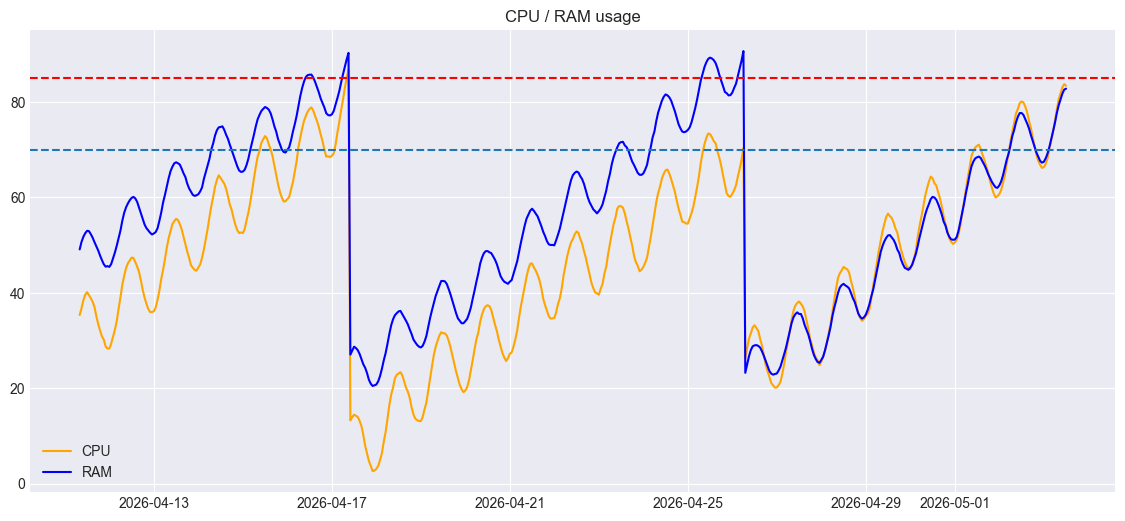

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df_all["timestamp"], df_all["cpu"], label="CPU", color="orange")
plt.plot(df_all["timestamp"], df_all["mem"], label="RAM", color="blue")

plt.axhline(70, linestyle="--")
plt.axhline(85, linestyle="--", color="red")

plt.legend()
plt.title("CPU / RAM usage")

plt.show()

Probailitéss Modèles

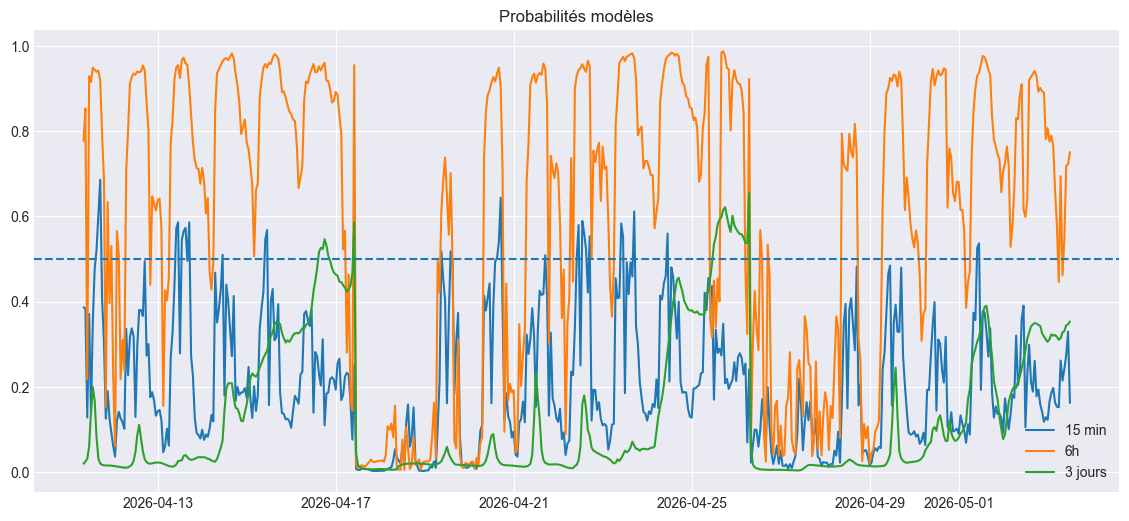

In [16]:
plt.figure(figsize=(14,6))

plt.plot(df_all["timestamp"], df_all["p15"], label="15 min")
plt.plot(df_all["timestamp"], df_all["p360"], label="6h")
plt.plot(df_all["timestamp"], df_all["p3d"], label="3 jours")

plt.axhline(0.5, linestyle="--")

plt.legend()
plt.title("Probabilités modèles")

plt.show()

Alertes

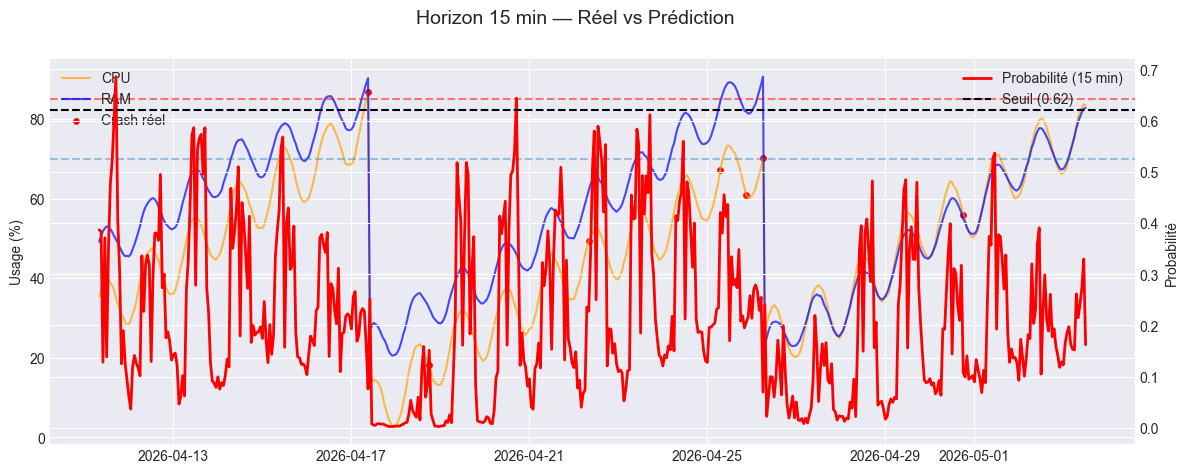

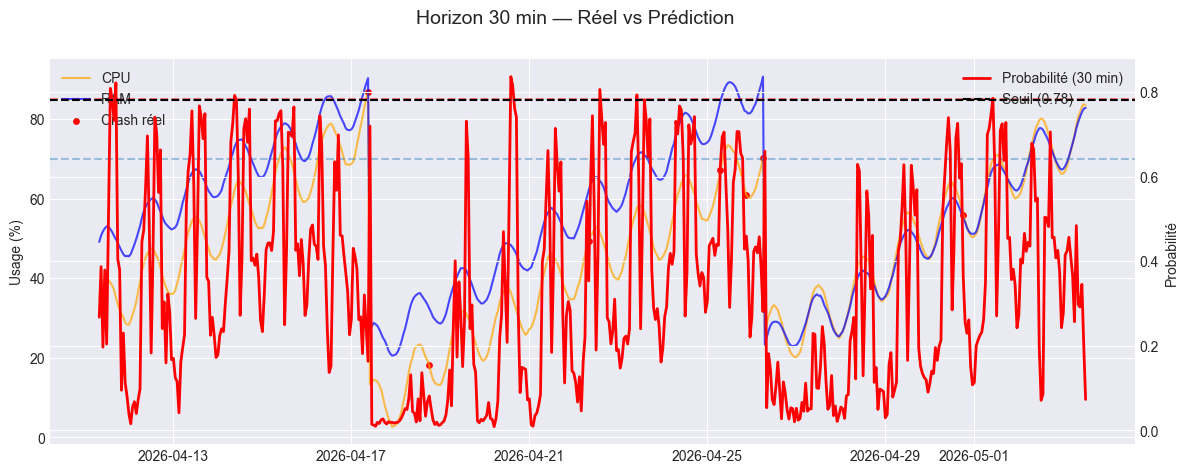

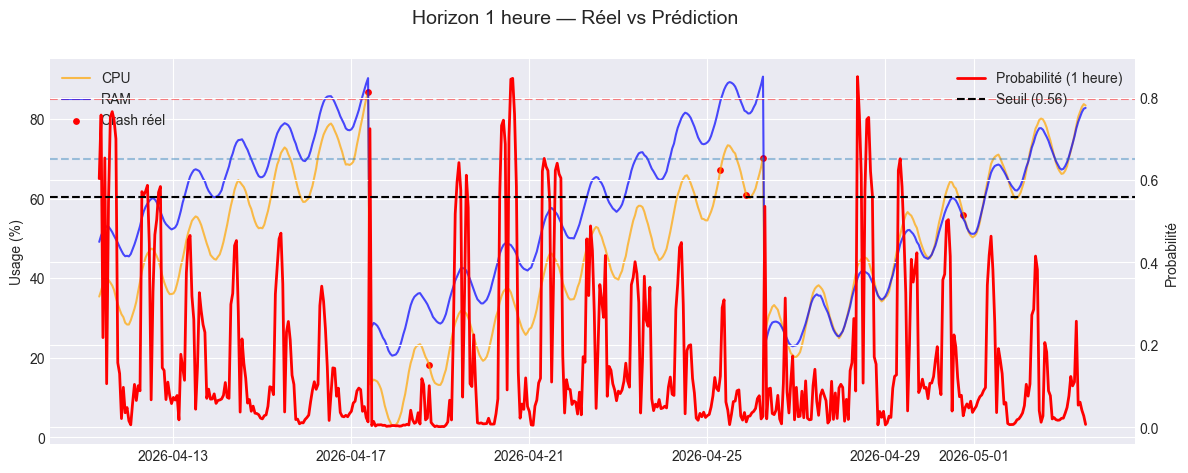

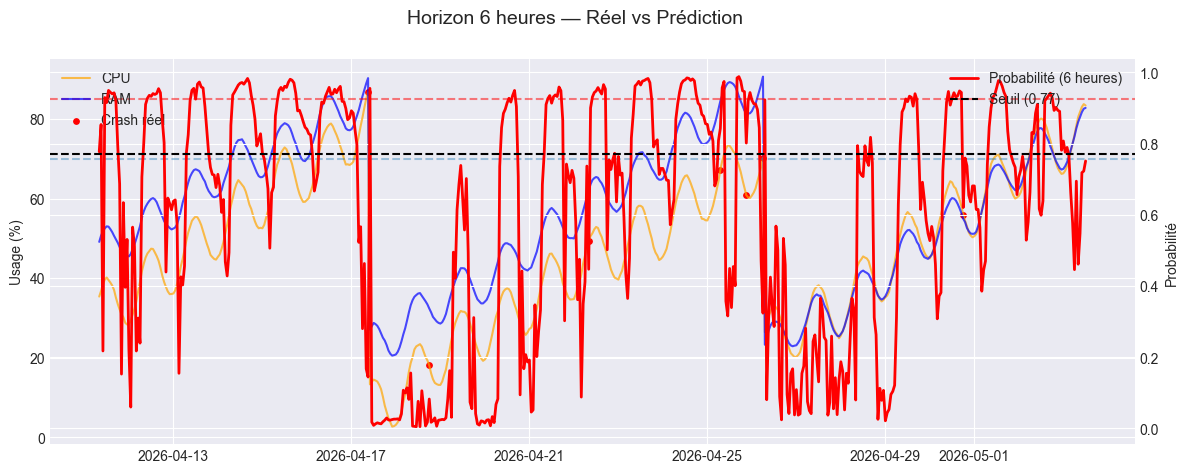

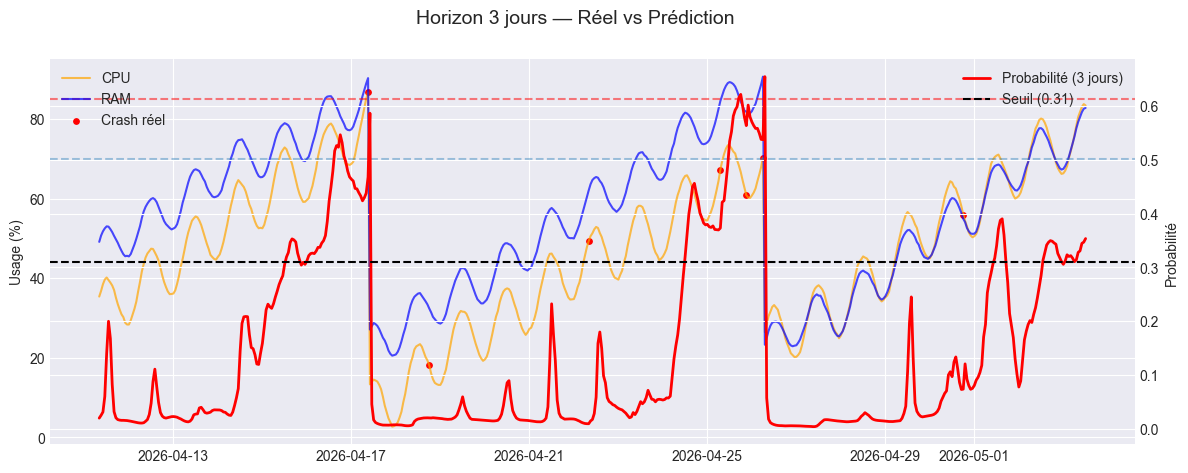

In [22]:
horizons = {
    "15 min": ("p15", 0.62),
    "30 min": ("p30", 0.78),
    "1 heure": ("p60", 0.56),
    "6 heures": ("p360", 0.77),
    "3 jours": ("p3d", 0.31),
}

for title, (col, threshold) in horizons.items():
    
    if col not in df_all.columns:
        print(f"⚠️ colonne {col} absente")
        continue

    fig, ax1 = plt.subplots(figsize=(14,5))

    # =========================
    # AXE 1 : CPU / RAM
    # =========================
    ax1.plot(df_all["timestamp"], df_all["cpu"],
             color="orange", label="CPU", alpha=0.7)
    
    ax1.plot(df_all["timestamp"], df_all["mem"],
             color="blue", label="RAM", alpha=0.7)

    ax1.axhline(70, linestyle="--", alpha=0.4)
    ax1.axhline(85, linestyle="--", color="red", alpha=0.5)

    ax1.set_ylabel("Usage (%)")

    # =========================
    # AXE 2 : PROBABILITÉ
    # =========================
    ax2 = ax1.twinx()

    ax2.plot(df_all["timestamp"], df_all[col],
             color="red", label=f"Probabilité ({title})", linewidth=2)

    ax2.axhline(threshold, linestyle="--", color="black",
                label=f"Seuil ({threshold})")

    ax2.set_ylabel("Probabilité")

    # =========================
    # INCIDENTS RÉELS
    # =========================
    incidents = df_all[df_all["real_status"] == "CRITICAL"]

    ax1.scatter(incidents["timestamp"], incidents["cpu"],
                color="red", s=15, label="Crash réel")

    # =========================
    # TITRE & LEGEND
    # =========================
    fig.suptitle(f"Horizon {title} — Réel vs Prédiction", fontsize=14)

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    

    plt.show()

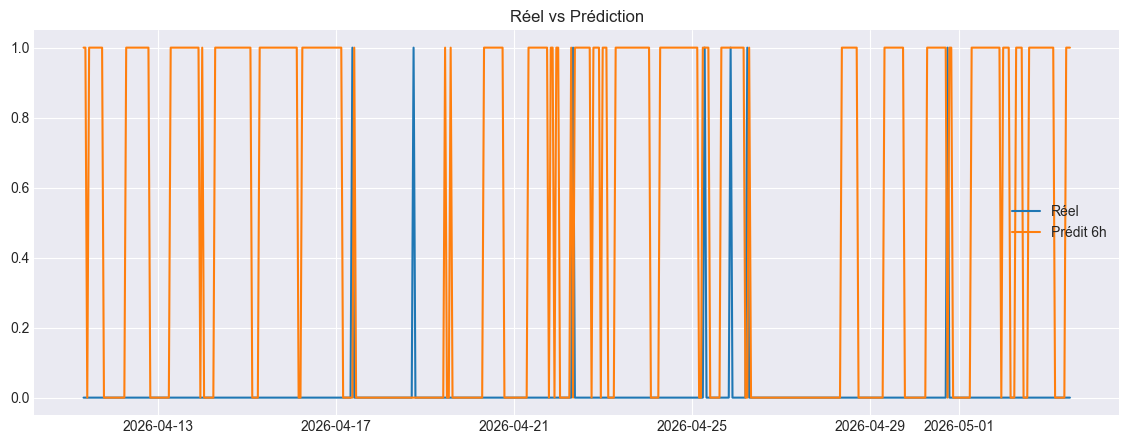

In [17]:
real = (df_all["real_status"] == "CRITICAL").astype(int)
pred = (df_all["p360"] > 0.7).astype(int)


plt.figure(figsize=(14,5))

plt.plot(df_all["timestamp"], real, label="Réel")
plt.plot(df_all["timestamp"], pred, label="Prédit 6h")

plt.legend()
plt.title("Réel vs Prédiction")

plt.show()

Comparaison Réel vs Prédiciton

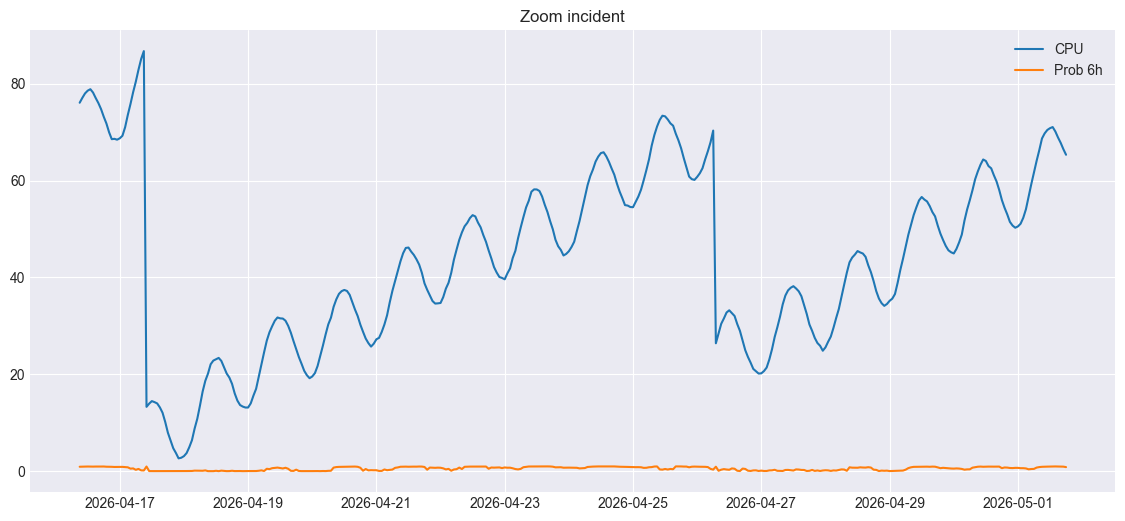

In [18]:
incident = df_all[df_all["real_status"] == "CRITICAL"]

start = incident["timestamp"].min() - pd.Timedelta(hours=24)
end   = incident["timestamp"].max() + pd.Timedelta(hours=24)

zoom = df_all[(df_all["timestamp"] >= start) & (df_all["timestamp"] <= end)]

plt.figure(figsize=(14,6))

plt.plot(zoom["timestamp"], zoom["cpu"], label="CPU")
plt.plot(zoom["timestamp"], zoom["p360"], label="Prob 6h")

plt.legend()
plt.title("Zoom incident")

plt.show()

Zoom incdient

In [ ]:
incident = df_all[df_all["LOCAL_STATUS"] == "CRITICAL"]

start = incident["timestamp"].min() - pd.Timedelta(hours=24)
end   = incident["timestamp"].max() + pd.Timedelta(hours=24)

zoom = df_all[(df_all["timestamp"] >= start) & (df_all["timestamp"] <= end)]

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(zoom["timestamp"], zoom["CPU_USAGE_PERCENT"], label="CPU")
ax.plot(zoom["timestamp"], zoom["p360"], label="Prob 6h")

ax.set_title("Zoom autour d’un incident")
ax.legend()

plt.show()